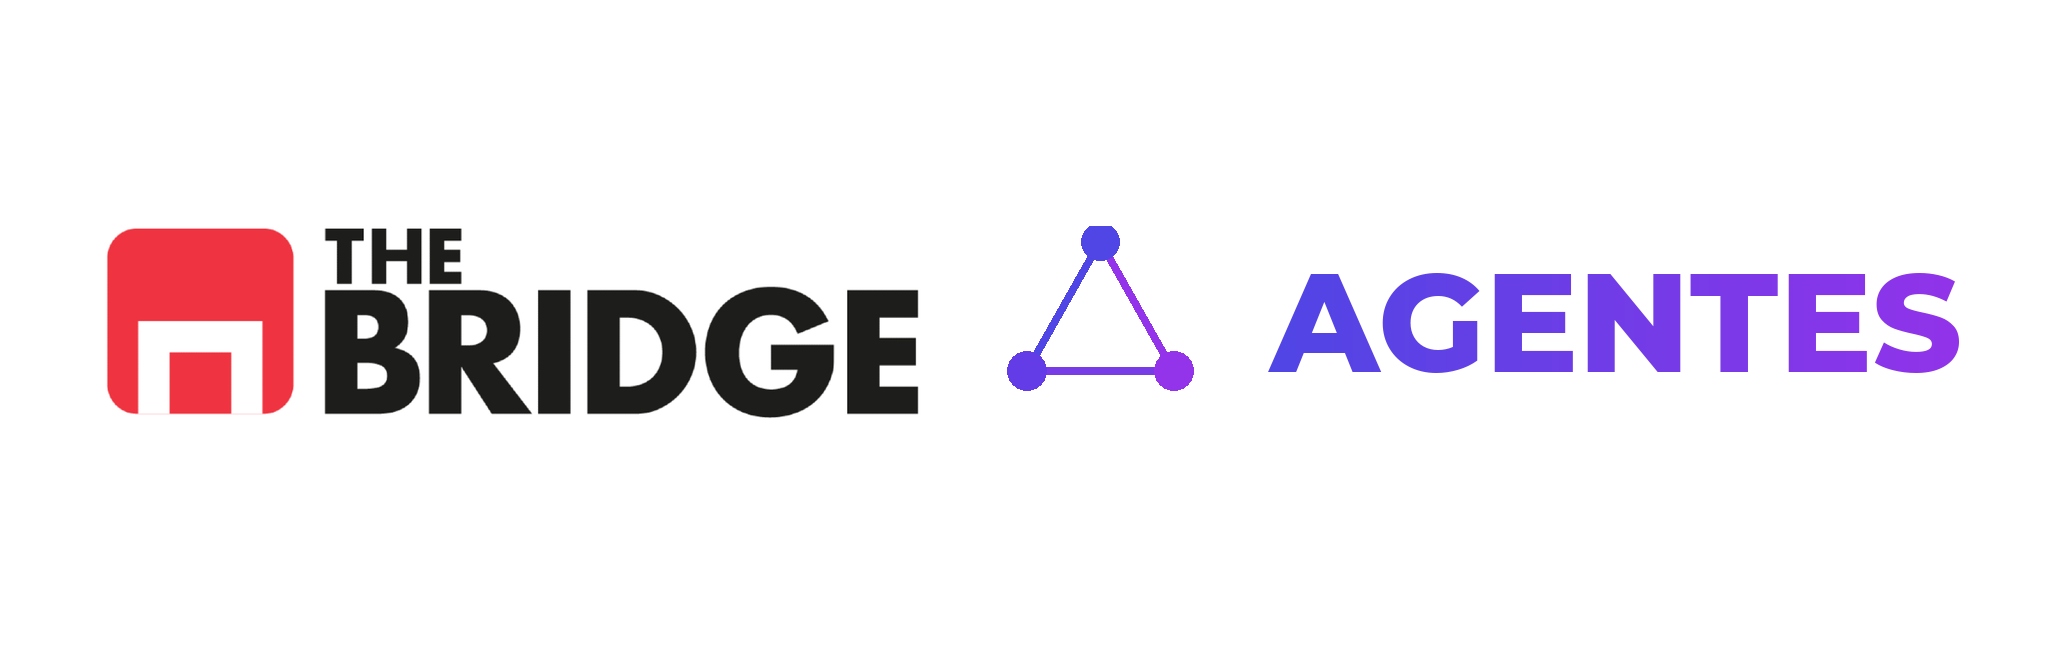

## 1) Setup

In [ ]:
%pip install -q google-genai python-dotenv

In [1]:
import copy
import json
import os
from getpass import getpass

from dotenv import load_dotenv
from google import genai

load_dotenv()

if not os.getenv("GEMINI_API_KEY"):
    os.environ["GEMINI_API_KEY"] = getpass("Pega tu GEMINI_API_KEY: ")

MODELO = "gemini-3.1-flash-lite"

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])
print("Listo. Modelo:", MODELO)

Listo. Modelo: gemini-3.1-flash-lite


## 2) El estado del Agente (la memoria de la tarea)

Es un diccionario normal de Python. Empieza casi vacío y se va rellenando.

Para **terminar** necesitamos: `intereses`, `presupuesto` y `zona`.  
La duración es opcional: si el usuario no la dice, el LLM puede sugerirla al cerrar el plan.

In [2]:
# Estado inicial del agente
def crear_estado(pedido):
    """Estado al empezar la conversación."""
    return {
        "objetivo": "Planificar una tarde cultural",
        "pedido_original": pedido,
        "preferencias": {
            "intereses": None,
            "presupuesto": None,
            "zona": None,
            "duracion_horas": None,
        },
        "plan": [],
        "respuesta": "",
        "done": False,
    }

# Comprueba si el estado ya tiene datos mínimos para que finalice el agente
def tenemos_datos_minimos(estado):
    """¿Ya hay intereses, presupuesto y zona?"""
    prefs = estado["preferencias"]
    intereses = prefs.get("intereses") or []
    return (
        len(intereses) >= 1
        and prefs.get("presupuesto")
        and prefs.get("zona")
    )


# Prueba rápida
ejemplo = crear_estado("Quiero una tarde cultural.")
print(json.dumps(ejemplo, ensure_ascii=False, indent=2))
print("¿Datos mínimos?", tenemos_datos_minimos(ejemplo))

{
  "objetivo": "Planificar una tarde cultural",
  "pedido_original": "Quiero una tarde cultural.",
  "preferencias": {
    "intereses": null,
    "presupuesto": null,
    "zona": null,
    "duracion_horas": null
  },
  "plan": [],
  "respuesta": "",
  "done": false
}
¿Datos mínimos? False


## 3) Leer el JSON que devuelve el modelo

A veces Gemini envuelve el JSON en \`\`\`json ... \`\`\`. Esta función lo limpia y lo convierte en un `dict`.

In [3]:
def leer_json(texto):
    """Convierte el texto del LLM en un diccionario."""
    texto = texto.strip()

    # Quitar ```json ... ``` si viene así
    if texto.startswith("```"):
        lineas = texto.splitlines()
        # quita primera y última línea (los ```)
        texto = "\n".join(lineas[1:-1]).strip()

    return json.loads(texto)


# Prueba
print(leer_json('{"respuesta": "hola", "plan": []}'))

{'respuesta': 'hola', 'plan': []}


## 4) Actualizar el estado

El LLM no modifica el estado directamente. **Copiamos** el estado y aplicamos solo preferencias, plan y respuesta.  Se devuelve el nuevo estado generado.

In [4]:
def actualizar_estado(estado, cambios):
    """Devuelve un estado nuevo con los cambios aplicados.

    No tocamos `done`: eso lo decide Python después.
    """
    nuevo = copy.deepcopy(estado)  # copia para no romper el anterior

    # 1) Preferencias: se van acumulando
    prefs_nuevas = cambios.get("preferencias") or {}
    for clave, valor in prefs_nuevas.items():
        if valor is not None:
            nuevo["preferencias"][clave] = valor

    # 2) Plan: si viene una lista, la sustituimos
    if isinstance(cambios.get("plan"), list):
        nuevo["plan"] = cambios["plan"]

    # 3) Texto para el usuario
    if "respuesta" in cambios:
        nuevo["respuesta"] = cambios["respuesta"]

    return nuevo

## 5) Calcular `done` en Python (guardrail)

El LLM **no** decide si hemos terminado. Solo rellena preferencias, plan y respuesta.  
Nosotros ponemos `done=True` solo si:

- Hay datos mínimos
- El plan tiene al menos 2 ítems.

In [5]:
def calcular_done(estado):
    """Guardrail: Decidimos si la tarea ha terminado."""
    nuevo = copy.deepcopy(estado)
    plan = nuevo.get("plan") or []
    nuevo["done"] = tenemos_datos_minimos(nuevo) and len(plan) >= 2
    return nuevo

## 6) Llamar a Gemini

Le pasamos el estado + el mensaje del usuario.  
Nos tiene que devolver **solo JSON**.

In [6]:
INSTRUCCIONES = """
Eres un planificador de tardes culturales.
No tienes bases de datos. Propón ideas genéricas (sin horarios inventados).

Responde SOLO con un JSON (sin markdown) con esta forma:
{
  "preferencias": {
    "intereses": ["..."] o null,
    "presupuesto": "gratis_o_barato" o "medio" o "alto" o null,
    "zona": "..." o null,
    "duracion_horas": numero o null
  },
  "plan": [],
  "respuesta": "texto corto para el usuario"
}

Reglas simples:
- No inventes preferencias que el usuario no haya dicho.
- Si faltan intereses, presupuesto o zona: plan=[], y pregunta (máximo 2 preguntas).
- No rellenes el plan hasta que haya intereses+presupuesto+zona y el usuario confirme (sí / adelante).
- Cuando cierres: plan con 2 a 4 ítems. duracion_horas es opcional; si falta, sugiere un número razonable (p. ej. 3).
- No incluyas el campo "done": lo calcula el código.
""".strip()


def preguntar_al_modelo(estado, mensaje_usuario):
    """Una llamada a Gemini → dict con cambios."""
    prompt = (
        INSTRUCCIONES
        + "\n\nESTADO ACTUAL:\n"
        + json.dumps(estado, ensure_ascii=False, indent=2)
        + "\n\nMENSAJE DEL USUARIO:\n"
        + mensaje_usuario
        + "\n\nDevuelve el JSON:"
    )

    respuesta = client.models.generate_content(
        model=MODELO,
        contents=prompt,
        config={"temperature": 0.3},
    )
    texto = (respuesta.text or "").strip()
    return leer_json(texto)

## 7) Conversación de ejemplo (4 turnos)

| Turno | Usuario | Qué debería pasar |
|-------|---------|-------------------|
| 1 | Quiero una tarde cultural. | El agente pregunta |
| 2 | Cine o música, barato. | Guarda intereses y presupuesto |
| 3 | Zona centro. | Ya casi tiene todo |
| 4 | Sí, adelante, 3 horas. | Escribe el plan → Python pone `done=True` |

En cada turno verás la **respuesta** del agente y el **estado** completo.

In [7]:
mensajes = [
    "Quiero una tarde cultural.",
    "Cine o música en vivo, mejor barato.",
    "Zona centro.",
    "Sí, adelante, unas 3 horas.",
]

estado = crear_estado("Quiero una tarde cultural.")

for numero, mensaje in enumerate(mensajes, start=1):
    print("=" * 50)
    print(f"TURNO {numero}")
    print("Usuario:", mensaje)

    cambios = preguntar_al_modelo(estado, mensaje)
    estado = actualizar_estado(estado, cambios)
    estado = calcular_done(estado)

    print("Agente:", estado["respuesta"])
    print("Estado:")
    print(json.dumps(estado, ensure_ascii=False, indent=2))
    print()

    if estado["done"]:
        print("Fin: done=True")
        break

TURNO 1
Usuario: Quiero una tarde cultural.
Agente: ¡Me encantaría ayudarte a planear tu tarde cultural! Para empezar, ¿qué tipo de actividades prefieres (museos, teatro, música, arquitectura) y en qué zona de la ciudad te gustaría estar?
Estado:
{
  "objetivo": "Planificar una tarde cultural",
  "pedido_original": "Quiero una tarde cultural.",
  "preferencias": {
    "intereses": null,
    "presupuesto": null,
    "zona": null,
    "duracion_horas": null
  },
  "plan": [],
  "respuesta": "¡Me encantaría ayudarte a planear tu tarde cultural! Para empezar, ¿qué tipo de actividades prefieres (museos, teatro, música, arquitectura) y en qué zona de la ciudad te gustaría estar?",
  "done": false
}

TURNO 2
Usuario: Cine o música en vivo, mejor barato.
Agente: ¡Excelente elección! Solo me falta saber en qué zona de la ciudad prefieres realizar estas actividades para poder darte opciones concretas. ¿Podrías indicármela?
Estado:
{
  "objetivo": "Planificar una tarde cultural",
  "pedido_origin

## Recuerda

| Concepto | Qué es |
|----------|--------|
| Historial de chat | Lista de mensajes (para mostrar la charla) |
| Estado (`estado`) | Dict con preferencias, plan y `done` |

- El LLM **propone** preferencias, plan y respuesta (JSON).
- Desde nuestro códgo en Python se **guarda** y **decide**  cándo cambiar `done` a True para que termine la conversación con el agente (`calcular_done`).